# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model_ricard as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 4,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 1,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,
     'T_crossover_ratio': 0.1,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [-1.0,1.0,1.0,1.0],
     'input_set':[[-1,-1],[-1,1],[1,-1],[1,1]],
     'ff_iter': 4,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'state_bound': [-10,+10],                    # boundaries on the possibile values of the state
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.2,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.1,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 400,
     'N_sol': 100}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean = m.evolution(par,verb=3,gen_verb=False)

Iteration #0...
Mean loss: 1.0001475298383884
Mean target distance: 1.0001475322074445
Parents indexes: [[86 20]
 [82 93]
 [21 99]
 [56 99]
 [76 45]
 [ 4 25]
 [82 43]
 [12 40]
 [98  0]
 [42  6]
 [ 7 14]
 [76 36]
 [18 49]
 [79 77]
 [ 6 83]
 [73 24]
 [40 50]
 [57 54]
 [22 50]
 [23  5]
 [70  7]
 [60 24]
 [56 38]
 [38 16]
 [24 90]
 [89 13]
 [13 30]
 [97 80]
 [84 39]
 [41 86]
 [46  3]
 [78 23]
 [95 49]
 [29 28]
 [ 5 71]
 [43 27]
 [12 70]
 [33 77]
 [21 52]
 [29 76]]
Selection Probabilities: [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01]
I

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 80


In [5]:
s = copy.deepcopy(solutions)
losses = []
for n,sol in enumerate(s[:20]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-1, -1] -> Output: 0.00897083466714177
Target distance:1.0089708346671418
Link cost:0.49759735790289045
Input: [-1, 1] -> Output: 0.01972538217053832
Target distance:0.9802746178294617
Link cost:0.49759735790289045
Input: [1, -1] -> Output: 0.009779459996369644
Target distance:0.9902205400036304
Link cost:0.49759735790289045
Input: [1, 1] -> Output: 0.020521652774469157
Target distance:0.9794783472255308
Link cost:0.49759735790289045
loss:0.9897360849314412
Solution #1
Input: [-1, -1] -> Output: 0.04867677698509976
Target distance:1.0486767769850998
Link cost:0.27672083186686014
Input: [-1, 1] -> Output: 0.04891975137903848
Target distance:0.9510802486209615
Link cost:0.27672083186686014
Input: [1, -1] -> Output: 0.04867372813769655
Target distance:0.9513262718623035
Link cost:0.27672083186686014
Input: [1, 1] -> Output: 0.048916703312177345
Target distance:0.9510832966878227
Link cost:0.27672083186686014
loss:0.9755416485390469
Solution #2
Input: [-1, -1] -> Output

In [6]:
print(f'Mean final loss: {np.mean(np.array(losses) < 100)}')

Mean final loss: 1.0


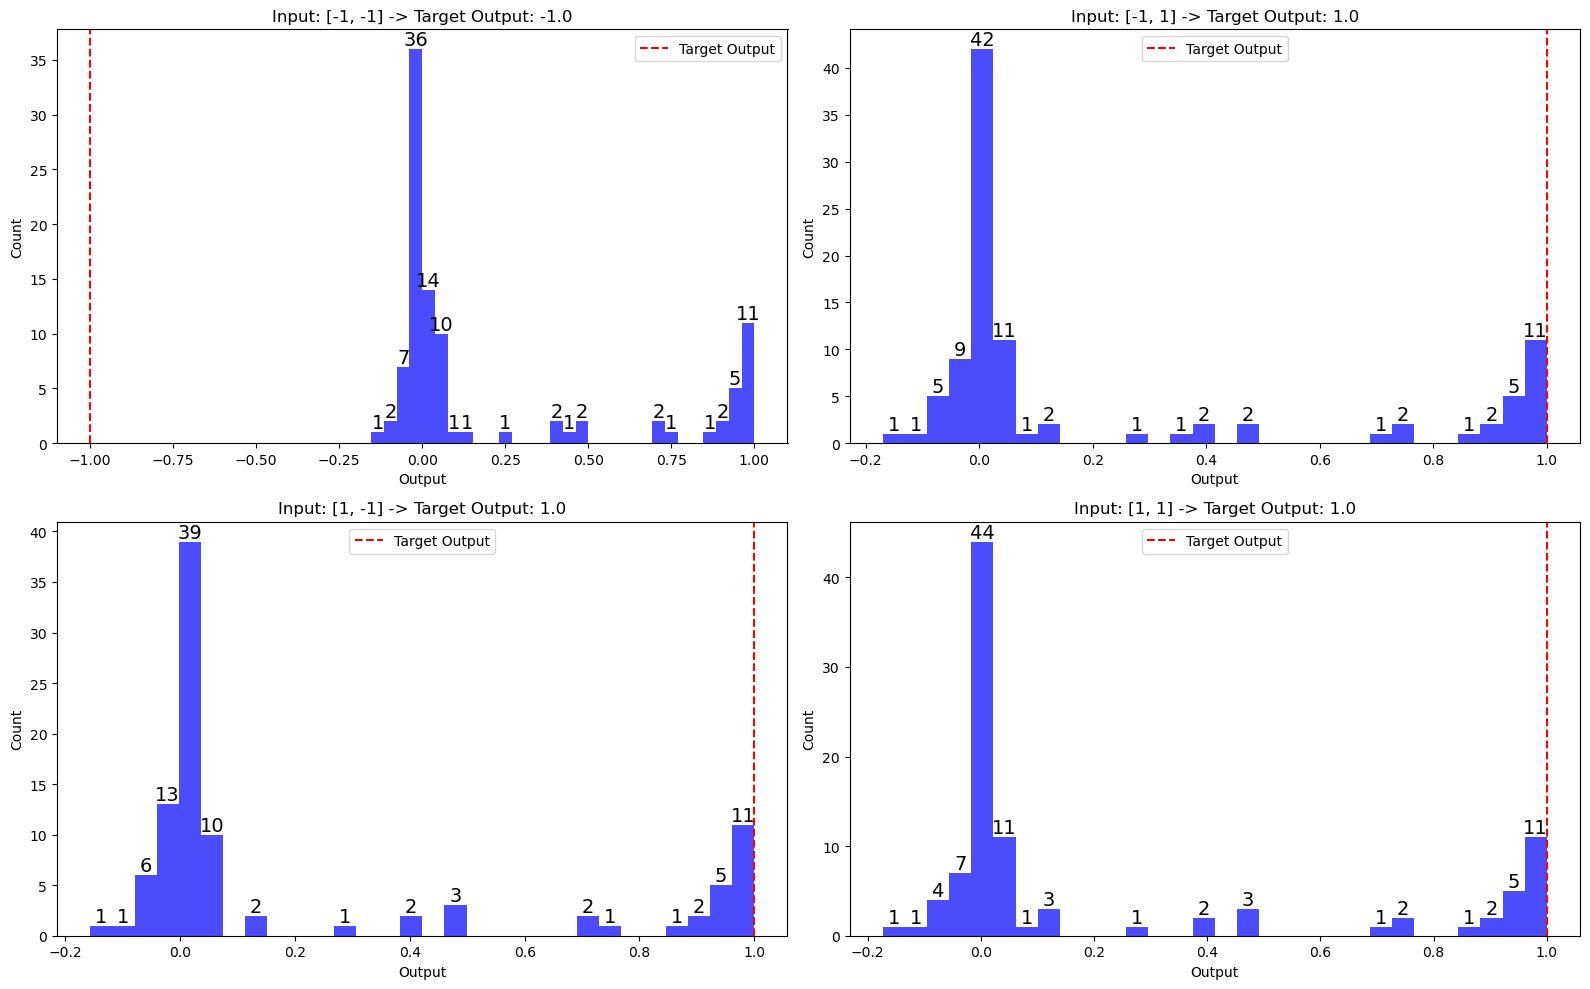

In [7]:
outputs = np.zeros((len(solutions),len(par['input_set'])))
for n,sol in enumerate(solutions):
    for i,input in enumerate(par['input_set']):
        output = m.ff(input,sol,par)
        outputs[n,i] = output

fig, axes = plt.subplots(2, len(par['input_set'])//2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par['target_set'][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r',linestyle='--')
    #ax.set_xticks(list(ax.get_xticks()) + [par['target_set'][i]])
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (patch.get_x() + patch.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=14)
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
print(f'Vertex numbers of inputs: 0,{par['L']}')
print(f'Vertex numbers of the output: {par['L']**2-1}')

Vertex numbers of inputs: 0,4
Vertex numbers of the output: 15


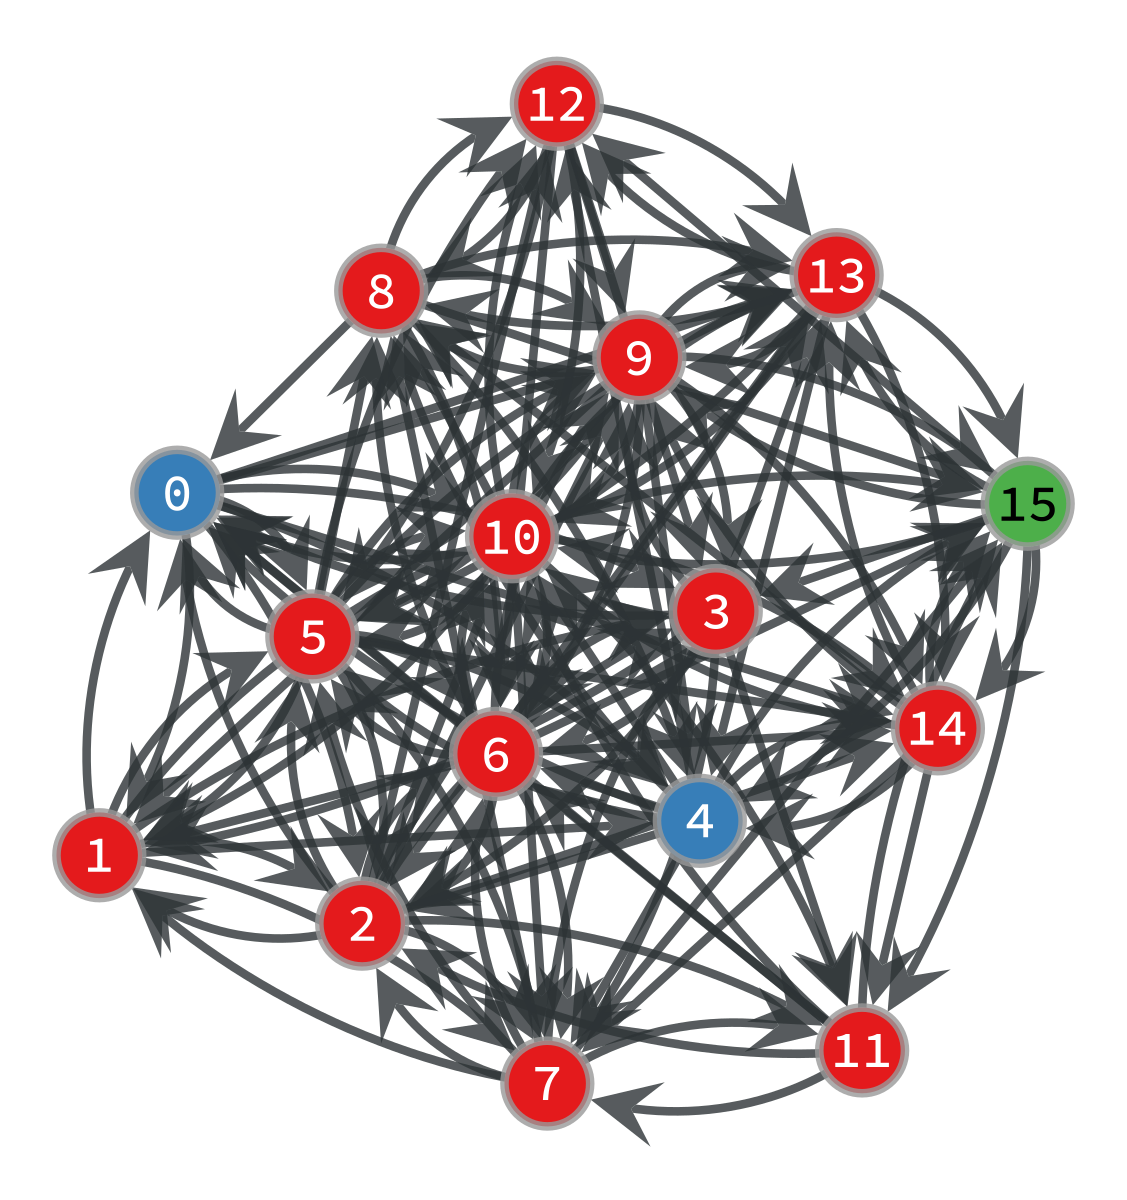

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f8d9a1f4690, at 0x7f8d9180f1c0>

In [9]:
graph = s[0].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(0)] = 1
highlight[graph.vertex(par['L'])] = 1
highlight[graph.vertex(graph.num_vertices()-1)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [10]:
print(f'Links density:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Links density:0.5625


In [11]:
for input in par['input_set']:
    output,_ = m.ff(input,s[2],par,verb=2)
    print(f'Input:{input} -> Output:{output}')

Input:[-1, -1] -> Output:0.8874564391747881
Input:[-1, 1] -> Output:0.8894595411411517
Input:[1, -1] -> Output:0.8858221549880201
Input:[1, 1] -> Output:0.8892351527599207


In [12]:
def plot_T(g:float,par:dict) -> None:
    """Function to plot the shape of the transfer function given the Fourier coefficients.

    Args:
        T (np.ndarray): array of the Fourier coefficients of A SINGLE cell.
        par (dict): simulation parameters.
    """
    new_fun = lambda x: par['gamma'] / (1+np.exp(-g*x)) - par['gamma']/2
    x = np.linspace(-100,100,1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()
        

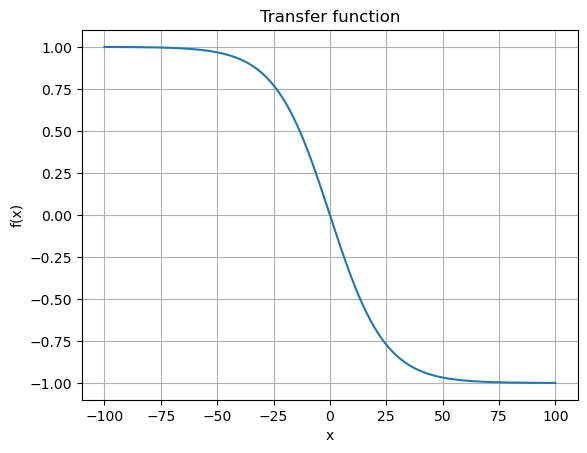

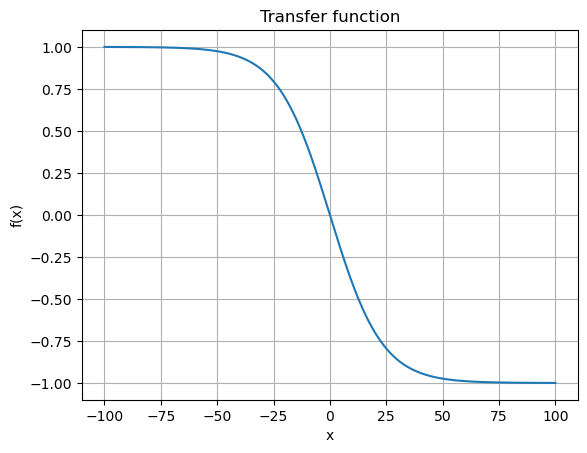

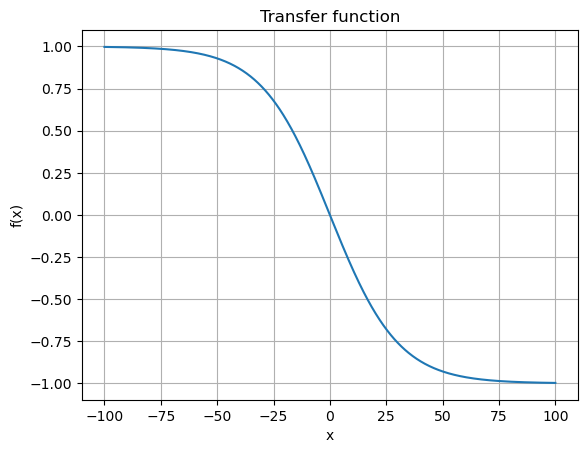

In [13]:
for i in range(3):
    plot_T(s[1].T[5+i],par)

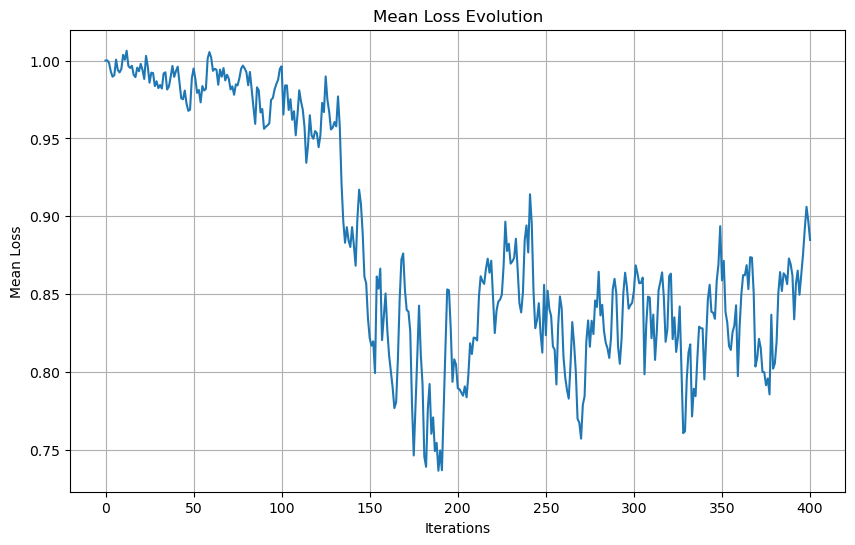

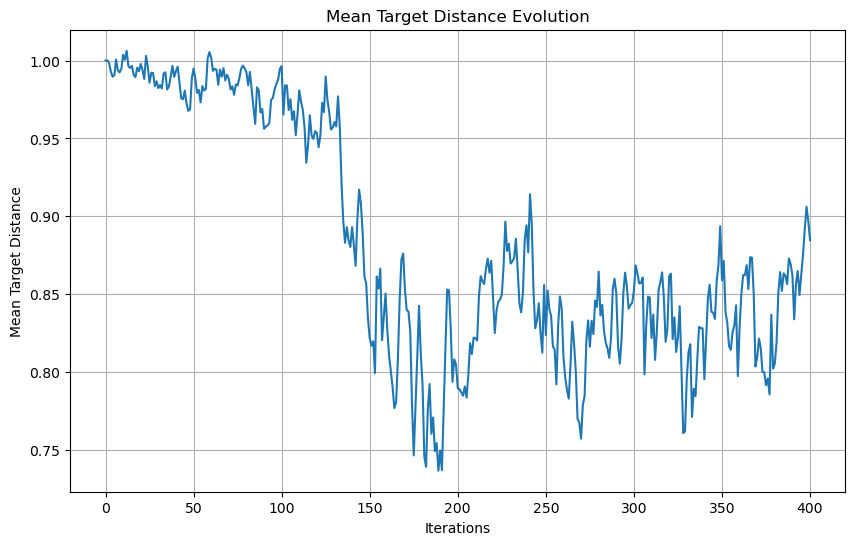

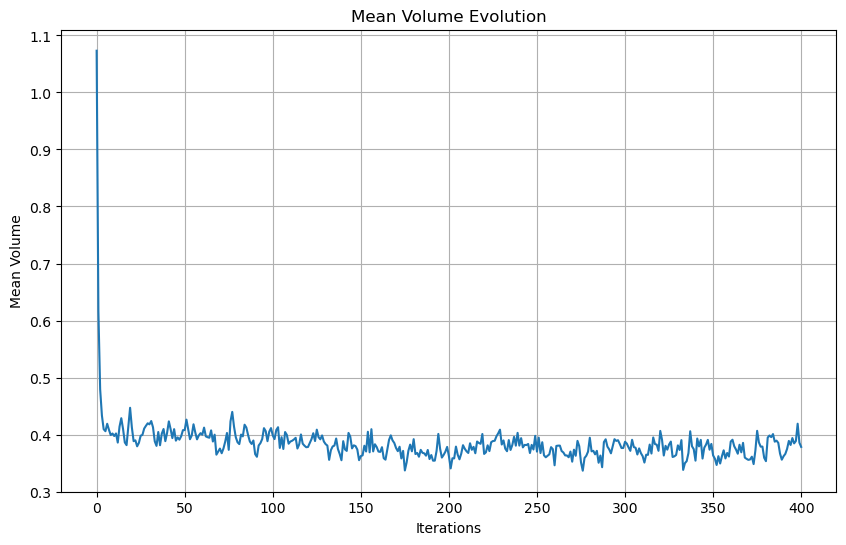

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(lmean)
plt.title('Mean Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Loss')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()